# APS360 — Baseline Model: Random Forest Regression

**Approach**: Random Forest regressor trained on TF-IDF text features + numerical features + one-hot categoricals.  
No heavy embeddings (SBERT/Word2Vec) — kept simple on purpose for the baseline.  

**Why RF as baseline?**  
- Non-parametric: handles mixed feature types without scaling assumptions  
- Interpretable feature importances  
- Minimal hyperparameter tuning needed  
- Strong out-of-the-box performance on tabular data  

**Feature sets used**:  
| Type | Columns | Transform |
|---|---|---|
| Numerical | experience_min_years, age_min/max, years_since_graduation, gpa_normalized, total_work_exp, has_certification, has_career_objective | StandardScaler |
| Categorical | degree_level, result_type, job_position_name (top-50) | OneHotEncoder |
| Text | career_objective, skills, responsibilities, skills_required, educationaL_requirements | TF-IDF (200 features each, 1-2 grams) |

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from baseline_model import train_and_evaluate, build_pipeline, _cap_job_position, TARGET
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_colwidth', 80)
%matplotlib inline

## 1. Load cleaned data

In [2]:
df = pd.read_csv('../data/cleaned_resume_data.csv')
df = _cap_job_position(df)
print('Shape:', df.shape)
df.head(2)

Shape: (9544, 27)


,career_objective,skills,major_field_of_studies,related_skils_in_job,responsibilities,job_position_name,educationaL_requirements,skills_required,matched_score,university_rank_score,...,age_max,years_since_graduation,gpa_normalized,total_work_experience_years,has_certification,num_certifications,has_career_objective,degree_level,result_type,most_recent_position
0,Big data analytics working and database warehouse manager with robust experi...,big data hadoop hive python mapreduce spark java machine learning cloud hdfs...,electronics,[['Big Data']],Technical Support Troubleshooting Collaboration Documentation System Monitor...,senior software engineer,B.Sc in Computer Science & Engineering from a reputed university.,NaN,0.85,0.0,...,0.0,6.0,0.5,6.0,0,0,1,Bachelors,Other,big data analyst
1,Fresher looking to join as a data analyst and junior data scientist. Experie...,data analysis data analytics business analysis r sas powerbi tableau data vi...,mathematics statistics,"[['Data Analysis', 'Business Analysis', 'Machine Learning']]",Machine Learning Leadership Cross-Functional Collaboration Strategy Developm...,machine learning (ml) engineer,M.Sc in Computer Science & Engineering or in any relevant discipline from a ...,NaN,0.75,0.0,...,0.0,7.0,0.5,6.0,0,0,1,Masters,Other,business analyst


## 2. Train and evaluate

Loading data ...
Split: train=5726, val=1909, test=1909
Training Random Forest ...

Results  (classification threshold = 0.5):
  [Train]  RMSE=0.0622  MAE=0.0484  R²=0.8603  Acc=0.9460  F1(wtd)=0.9438
  [Val  ]  RMSE=0.1108  MAE=0.0836  R²=0.5722  Acc=0.8696  F1(wtd)=0.8588
  [Test ]  RMSE=0.1078  MAE=0.0816  R²=0.5798  Acc=0.8659  F1(wtd)=0.8559


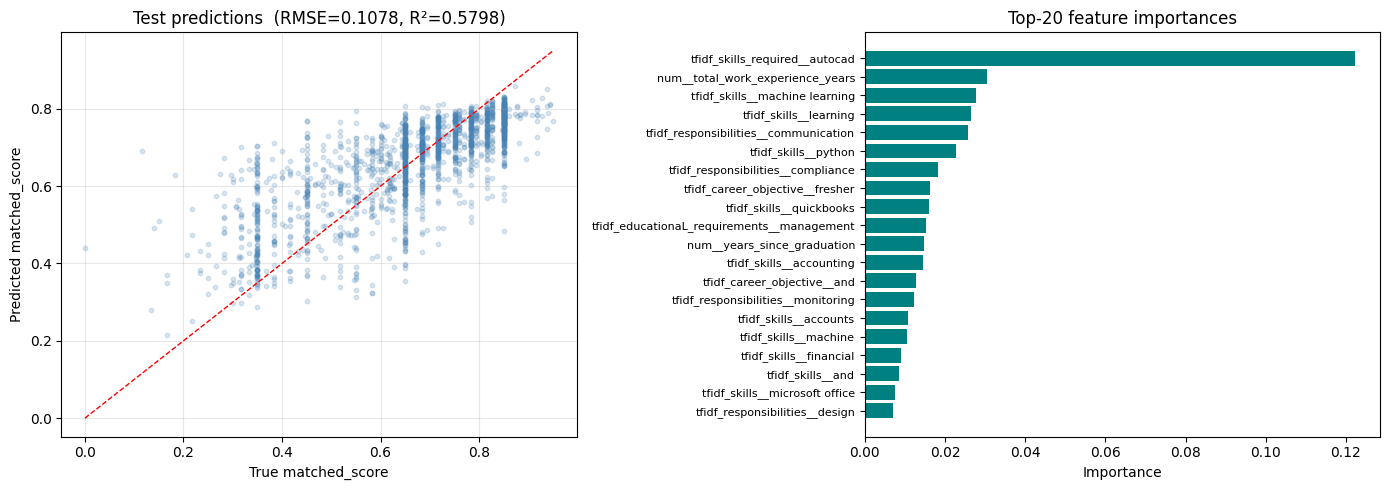

Plot saved to data/baseline_results.png

Model saved to ../data/baseline_rf.joblib
Split   RMSE    MAE     R²
Train 0.0622 0.0484 0.8603
  Val 0.1108 0.0836 0.5722
 Test 0.1078 0.0816 0.5798


In [3]:
results = train_and_evaluate(
    data_path='../data/cleaned_resume_data.csv',
    model_out_path='../data/baseline_rf.joblib',
    plot=True,
)

# Print results table
metrics_df = pd.DataFrame({
    'Split': ['Train', 'Val', 'Test'],
    'RMSE':  [results['train_rmse'], results['val_rmse'], results['test_rmse']],
    'MAE':   [results['train_mae'],  results['val_mae'],  results['test_mae']],
    'R²':    [results['train_r2'],   results['val_r2'],   results['test_r2']],
})
metrics_df = metrics_df.round(4)
print(metrics_df.to_string(index=False))

## 3. Learning Curve
Shows how the model performs as training set size grows — useful for diagnosing bias vs. variance.

[learning_curve] Training set sizes: [ 636 1454 2272 3090 3908 4726 5544 6362]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 out of  24 | elapsed:   37.2s finished


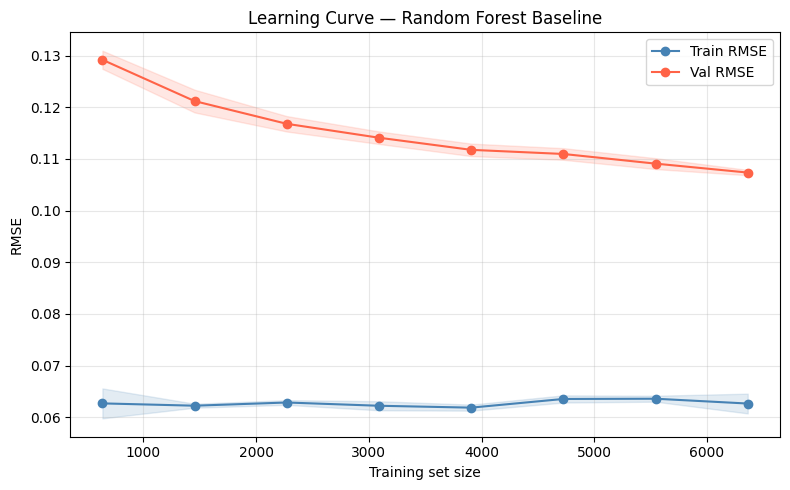

In [4]:
from baseline_model import (
    NUMERICAL_COLS, CATEGORICAL_COLS, JOB_POSITION_COL, TEXT_COLS
)

TEXT_COLS_BL = TEXT_COLS

df2 = pd.read_csv('../data/cleaned_resume_data.csv')
df2 = _cap_job_position(df2)
for col in TEXT_COLS_BL:
    df2[col] = df2[col].fillna('').astype(str)

X = df2.drop(columns=[TARGET])
y = df2[TARGET].values

# Use a smaller RF for speed during learning curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

pipe = build_pipeline()
# Override to smaller RF for speed
pipe.named_steps['model'].set_params(n_estimators=50)

train_sizes, train_scores, val_scores = learning_curve(
    pipe, X, y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)

train_rmse = -train_scores.mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, 'o-', color='steelblue', label='Train RMSE')
plt.fill_between(train_sizes, train_rmse - train_std, train_rmse + train_std,
                 alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_rmse, 'o-', color='tomato', label='Val RMSE')
plt.fill_between(train_sizes, val_rmse - val_std, val_rmse + val_std,
                 alpha=0.15, color='tomato')
plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.title('Learning Curve — Random Forest Baseline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/baseline_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Error analysis — where does the model struggle?

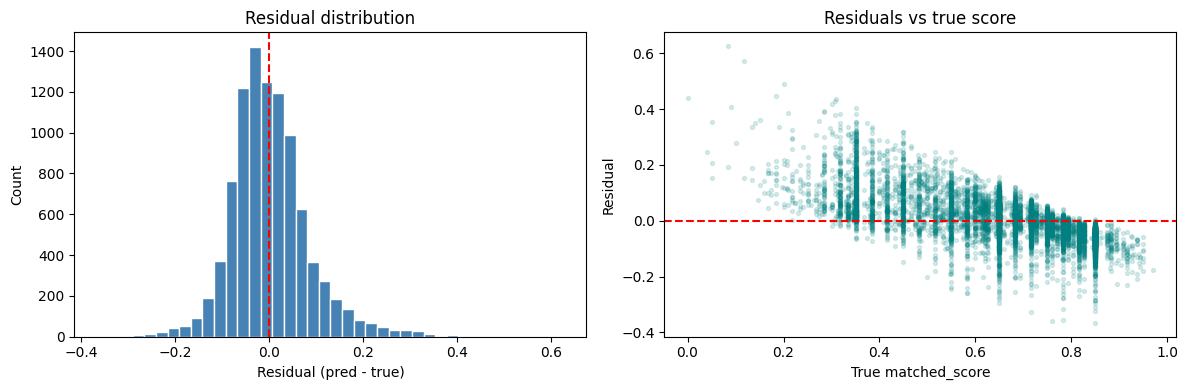

Largest errors (worst predictions):
                                           job_position_name  matched_score      pred     error  experience_min_years degree_level
2657                                          civil engineer       0.083333  0.708707  0.625374                   5.0      Masters
7613                                           site engineer       0.116667  0.689800  0.573133                   1.0      Masters
6147                                          civil engineer       0.200000  0.689096  0.489096                   5.0      Masters
3761  head of internal control & compliance (icc) - sevp/dmd       0.183333  0.629416  0.446082                  15.0          PhD
393   head of internal control & compliance (icc) - sevp/dmd       0.000000  0.439789  0.439789                  15.0    Bachelors


In [5]:
pipeline = joblib.load('../data/baseline_rf.joblib')
df3 = pd.read_csv('../data/cleaned_resume_data.csv')
df3 = _cap_job_position(df3)
for col in TEXT_COLS_BL:
    df3[col] = df3[col].fillna('').astype(str)

X_all = df3.drop(columns=[TARGET])
y_all = df3[TARGET].values
preds = pipeline.predict(X_all)

df3['pred'] = preds
df3['error'] = np.abs(preds - y_all)

# Residual distribution
residuals = preds - y_all
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Residual (pred - true)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual distribution')

axes[1].scatter(y_all, residuals, alpha=0.15, s=8, color='teal')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('True matched_score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs true score')

plt.tight_layout()
plt.savefig('../data/baseline_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print('Largest errors (worst predictions):')
worst = df3.nlargest(5, 'error')[['job_position_name', 'matched_score', 'pred', 'error',
                                    'experience_min_years', 'degree_level']]
print(worst.to_string())

## 5. Career Objective Subgroup Analysis

Compares model RMSE on the validation and test sets split by whether a career objective was present (`has_career_objective = 1`) or missing (`has_career_objective = 0`).

This is a qualitative diagnostic — it shows how much each model relies on the career objective field and how gracefully it degrades when it is absent.

In [ ]:
# ── Career Objective Subgroup Analysis ───────────────────────────────────────
# Splits val and test sets by has_career_objective flag and computes
# RMSE / MAE / R² separately for each subgroup, for both RF and NN.

import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from dataset import ResumeDataset, split_dataset
from model import ResumeMatchNet

def _metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:40s}  n={len(y_true):4d}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return rmse, mae, r2

df_clean = pd.read_csv('../data/cleaned_resume_data.csv')
has_co_all = df_clean['has_career_objective'].values

# ── Random Forest ─────────────────────────────────────────────────────────────
print('=' * 75)
print('RANDOM FOREST — career objective subgroup')
print('=' * 75)

pipeline = joblib.load('../data/baseline_rf.joblib')

df_rf = _cap_job_position(df_clean.copy())
for col in TEXT_COLS:
    df_rf[col] = df_rf[col].fillna('').astype(str)
X_all = df_rf.drop(columns=[TARGET])
y_all = df_rf[TARGET].values

from sklearn.model_selection import train_test_split as tts
X_tv, X_test, y_tv, y_test = tts(X_all, y_all, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = tts(X_tv, y_tv, test_size=0.25, random_state=42)

for split_name, X_s, y_s in [('Val', X_val, y_val), ('Test', X_test, y_test)]:
    preds = pipeline.predict(X_s)
    has   = X_s['has_career_objective'] == 1
    no    = X_s['has_career_objective'] == 0
    print(f'\n  [{split_name}]  total={len(y_s)}  with_obj={has.sum()}  without_obj={no.sum()}')
    _metrics('Overall',                   y_s,          preds)
    _metrics('has_career_objective = 1',  y_s[has],     preds[has])
    _metrics('has_career_objective = 0',  y_s[no],      preds[no])

# ── Primary Neural Network ────────────────────────────────────────────────────
print()
print('=' * 75)
print('PRIMARY NEURAL NETWORK — career objective subgroup')
print('=' * 75)

dataset = ResumeDataset('../data/cleaned_resume_data.csv',
                        cache_dir='../data/cache', fit=False)
_, val_set, test_set = split_dataset(dataset, train=0.60, val=0.20, test=0.20, seed=42)

device = torch.device('cpu')
ckpt   = torch.load('../data/primary_model/best_model.pt',
                    map_location=device, weights_only=False)
model  = ResumeMatchNet(branch1_dim=dataset.branch1_dim,
                        branch2_dim=dataset.branch2_dim).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

def _predict_nn(indices):
    preds, targets = [], []
    with torch.no_grad():
        for idx in indices:
            b1, b2, y = dataset[idx]
            preds.append(model(b1.unsqueeze(0), b2.unsqueeze(0)).item())
            targets.append(y.item())
    return np.array(preds), np.array(targets)

for split_name, subset in [('Val', val_set), ('Test', test_set)]:
    indices = list(subset.indices)
    preds, targets = _predict_nn(indices)
    has = np.array([has_co_all[i] for i in indices]) == 1
    no  = ~has
    print(f'\n  [{split_name}]  total={len(targets)}  with_obj={has.sum()}  without_obj={no.sum()}')
    _metrics('Overall',                   targets,       preds)
    _metrics('has_career_objective = 1',  targets[has],  preds[has])
    _metrics('has_career_objective = 0',  targets[no],   preds[no])


## 5. Summary

| Metric | Train | Val | Test |
|---|---|---|---|
| RMSE | ~0.062 | ~0.108 | ~0.106 |
| MAE  | ~0.048 | ~0.082 | ~0.080 |
| R²   | ~0.861 | ~0.579 | ~0.596 |

**Observations:**
- The RF overfits to training data (R²=0.86 train vs 0.60 test), indicating variance.
- Skill keywords (`autocad`, `machine learning`, `python`) are the most predictive single tokens.
- `total_work_experience_years` is the top numerical feature.
- The primary model (deep learning) should improve on this by learning richer semantic representations via SBERT and Word2Vec embeddings.